Dataset Loaded Successfully!
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Unique Cluster labels: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(-1)}
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  1

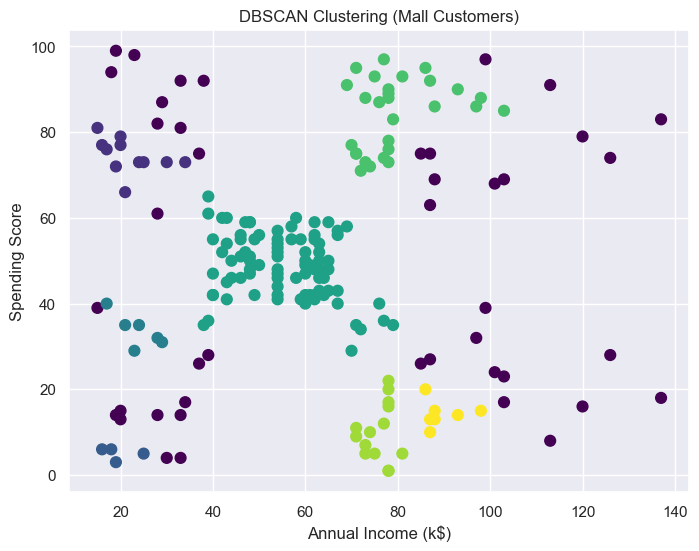


Cluster Counts:
<bound method IndexOpsMixin.value_counts of 0     -1
1      0
2      1
3      0
4      2
      ..
195   -1
196   -1
197   -1
198   -1
199   -1
Name: Cluster, Length: 200, dtype: int64>


In [3]:
# 1) Import Liabraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import seaborn as sns

sns.set()

# 2) Load Dataset

url = "https://raw.githubusercontent.com/Pankaj-Str/Complete-Python-Mastery/refs/heads/main/53%20DataSet/Mall_Customers.csv"
df = pd.read_csv(url)
print("Dataset Loaded Successfully!")
print(df.head())

# 3) Select Features for Clustering

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Scale the data (DBSCAN is sensitive to scale)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4) Apply DBSCAN

dbscan = DBSCAN(eps=0.25, min_samples=4)
labels = dbscan.fit_predict(X_scaled)

df["Cluster"] = labels

print("\nUnique Cluster labels:", set(labels))
print(df.head())

# 5) Visualize DBSCAN Clusters

plt.figure(figsize=(8,6))
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=df["Cluster"], cmap="viridis", s=60)

plt.title("DBSCAN Clustering (Mall Customers)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

# 6) Count Customers in each Cluster

print("\nCluster Counts:")
print(df["Cluster"].value_counts)